# Task 1 — Factor Concepts & Value Factor (Proxy)

**Week 2, Task 1** — builds the value signal on top of the Week 1 data pipeline.

## What this notebook does
1. Derives the shared monthly rebalance date grid.
2. Computes a contrarian value proxy score at each rebalance date.
3. Verifies insufficient-history exclusions (PLTR and any others).
4. Manual spot-checks on 3 tickers.
5. Cross-sectional distribution plot at a recent rebalance date.
6. Top 5 / bottom 5 tickers by value score at the most recent rebalance date.

## Proxy caveat (read first)
This project has no fundamental data (no book value, no earnings). The value
signal is the **negative of the trailing 12-month cumulative return** —
stocks that have fallen the most are treated as cheaper. This is labelled
`value_score_proxy` throughout. It is a real simplification, not a mistake,
but must never be confused with a true Fama-French HML or B/M value factor.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_utils import load_ohlcv, clean_ohlcv, resample_ohlcv
from factor_utils import get_rebalance_dates, compute_value_score
from universe import UNIVERSE, SP500_TOP50, START_DATE, END_DATE

pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams["figure.dpi"] = 120

## 1 · Load and clean data

In [2]:
daily = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)

print(f"Rows in cleaned  : {len(cleaned):,}")
print(f"Tickers          : {cleaned['ticker'].nunique()}")
print(f"Date range       : {cleaned['date'].min().date()} → {cleaned['date'].max().date()}")

Rows in cleaned  : 64,035
Tickers          : 51
Date range       : 2020-08-31 → 2025-08-29


## 2 · Rebalance date grid

All factor computations (value, momentum) and Task 3 quintile sorting use
this shared grid. It is derived from `resample_ohlcv` so it stays in sync
with the trading calendar validated in Week 1.

In [3]:
rebal_dates = get_rebalance_dates(cleaned)

print(f"Rebalance dates : {len(rebal_dates)} month-ends")
print(f"First           : {rebal_dates.min().date()}")
print(f"Last            : {rebal_dates.max().date()}")
print(f"\nFirst 5 : {[str(d.date()) for d in rebal_dates[:5]]}")
print(f"Last  5 : {[str(d.date()) for d in rebal_dates[-5:]]}")

Rebalance dates : 61 month-ends
First           : 2020-08-31
Last            : 2025-08-31

First 5 : ['2020-08-31', '2020-09-30', '2020-10-31', '2020-11-30', '2020-12-31']
Last  5 : ['2025-04-30', '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31']


## 3 · Compute value scores

`compute_value_score` returns tidy rows with:
- `trailing_return_proxy` = P_t / P_{t-12m} - 1  
- `value_score_proxy` = -trailing_return_proxy (high = cheaper under proxy)  
- `value_rank_proxy` = cross-sectional rank (1 = most "cheap")

Ticker-dates with insufficient history are excluded with a logged reason,
never silently NaN'd.

In [4]:
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

scores = compute_value_score(cleaned, lookback_months=12)

print(f"\nValue score rows  : {len(scores):,}")
print(f"Rebalance dates   : {scores['date'].nunique()}")
print(f"Tickers covered   : {scores['ticker'].nunique()}")
print(f"\nSample (first 5 rows):")
display(scores.head())

INFO  Rebalance dates: 61 month-ends (2020-08-31 → 2025-08-31)


INFO  Excluded 51 ticker(s) — only 0 months of data before 2020-08-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 1 months of data before 2020-09-30 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 2 months of data before 2020-10-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 3 months of data before 2020-11-30 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


...

INFO  Excluded 51 ticker(s) — only 11 months of data before 2021-07-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 1 ticker(s) — NaN price at 2021-08-31 or 2020-08-31 (IPO or data gap within lookback window): ['PLTR']


INFO  compute_value_score: 2498 records across 49 rebalance dates, 51 tickers (lookback=12 months)



Value score rows  : 2,498
Rebalance dates   : 49
Tickers covered   : 51

Sample (first 5 rows):


,date,ticker,trailing_return_proxy,value_score_proxy,value_rank_proxy
0,2021-08-31,AMGN,-0.083619,0.083619,1.000000
1,2021-08-31,MRK,-0.031472,0.031472,2.000000
2,2021-08-31,MA,-0.028744,0.028744,3.000000
3,2021-08-31,CRM,-0.027068,0.027068,4.000000
4,2021-08-31,AMZN,0.005746,-0.005746,5.000000


## 4 · Insufficient history — which tickers were excluded and when?

In [5]:
# For each rebalance date, how many tickers have a valid score?
coverage = scores.groupby("date")["ticker"].count().rename("n_valid")

# First date where all 51 tickers have a score
# (Universe = 51 tickers; SPY included)
full_coverage_dates = coverage[coverage == len(UNIVERSE)]

print(f"Total tickers in UNIVERSE : {len(UNIVERSE)}")
print(f"Rebalance dates with full coverage: {len(full_coverage_dates)}")

if full_coverage_dates.empty:
    print("No rebalance date has all 51 tickers — check coverage table.")
else:
    first_full = full_coverage_dates.index.min()
    print(f"First rebalance date with all {len(UNIVERSE)} tickers valid: {first_full.date()}")

print("\nCoverage at early rebalance dates (first 15):")
display(coverage.head(15).to_frame())

# Which tickers are missing at which early dates?
all_ticker_set = set(UNIVERSE)
early_excluded = []
for d, grp in scores.groupby("date"):
    covered = set(grp["ticker"])
    missing = all_ticker_set - covered
    if missing:
        early_excluded.append({"date": d, "missing_tickers": sorted(missing)})

excl_df = pd.DataFrame(early_excluded)
if excl_df.empty:
    print("\nNo tickers were excluded at any rebalance date.")
else:
    print(f"\nRebalance dates with at least one excluded ticker: {len(excl_df)}")
    display(excl_df)

Total tickers in UNIVERSE : 51
Rebalance dates with full coverage: 48
First rebalance date with all 51 tickers valid: 2021-09-30

Coverage at early rebalance dates (first 15):


,n_valid
date,
2021-08-31,50
2021-09-30,51
2021-10-31,51
2021-11-30,51
2021-12-31,51
2022-01-31,51
2022-02-28,51
2022-03-31,51
2022-04-30,51



Rebalance dates with at least one excluded ticker: 1


,date,missing_tickers
0,2021-08-31,[PLTR]


## 5 · Manual spot-checks — 3 tickers

Same discipline as Week 1 Task 4: independently compute the trailing
12-month return from the monthly price series and compare to
`compute_value_score()` output. Numbers must agree to floating-point precision.

In [6]:
# Build monthly price pivot once for spot-checks
monthly = resample_ohlcv(cleaned, freq="ME")
monthly_price = monthly.pivot(index="date", columns="ticker", values="adj_close")

SPOT_TICKERS = ["AAPL", "SPY", "PLTR"]
# Use the most recent rebalance date that exists for all three
SPOT_DATE = scores[scores["ticker"].isin(SPOT_TICKERS)].groupby("date")["ticker"].count()
SPOT_DATE = SPOT_DATE[SPOT_DATE == len(SPOT_TICKERS)].index.max()

print(f"Spot-check rebalance date: {SPOT_DATE.date()}")
print(f"{'Ticker':<8} {'p_prior':>12} {'p_now':>12} {'manual_ret':>12} {'fn_ret':>12} {'match':>8}")
print("-" * 66)

idx_pos = monthly_price.index.get_loc(SPOT_DATE)
prior_date = monthly_price.index[idx_pos - 12]

for ticker in SPOT_TICKERS:
    p_now   = monthly_price.loc[SPOT_DATE, ticker]
    p_prior = monthly_price.loc[prior_date, ticker]
    manual_ret = p_now / p_prior - 1

    fn_row = scores[(scores["date"] == SPOT_DATE) & (scores["ticker"] == ticker)]
    if fn_row.empty:
        print(f"{ticker:<8} {'(excluded)':>12}")
        continue
    fn_ret = fn_row["trailing_return_proxy"].iloc[0]
    match  = np.isclose(manual_ret, fn_ret, atol=1e-10)
    print(f"{ticker:<8} {p_prior:>12.4f} {p_now:>12.4f} {manual_ret:>12.6f} {fn_ret:>12.6f} {str(match):>8}")

print(f"\nPrior date used for lookback: {prior_date.date()}")
print(f"Rebalance date             : {SPOT_DATE.date()}")

Spot-check rebalance date: 2025-08-31
Ticker        p_prior        p_now   manual_ret       fn_ret    match
------------------------------------------------------------------
AAPL         227.1003     231.2856     0.018430     0.018430     True
SPY          550.6443     637.9810     0.158608     0.158608     True
PLTR          31.4800     156.7100     3.978082     3.978082     True

Prior date used for lookback: 2024-08-31
Rebalance date             : 2025-08-31


## 6 · Cross-sectional distribution at a recent rebalance date

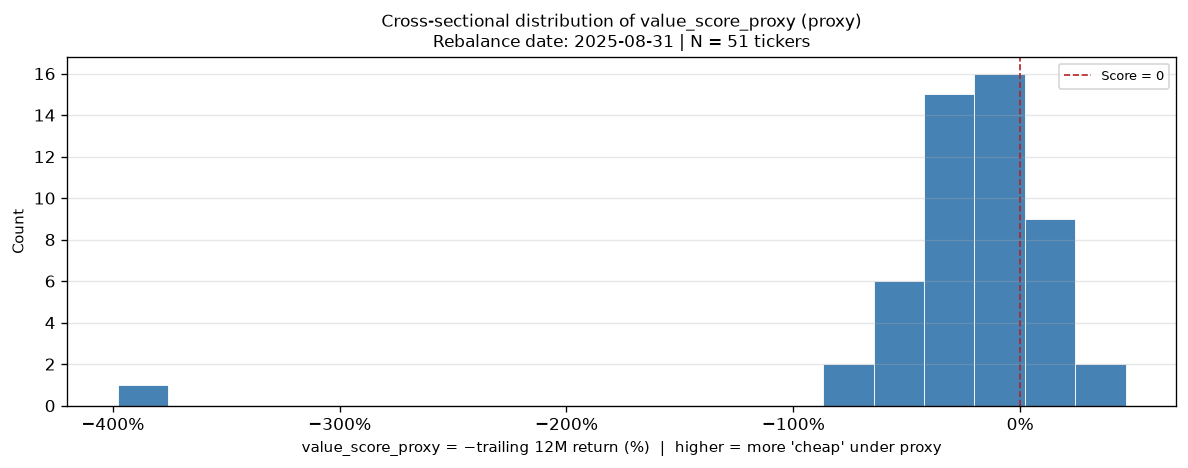


Cross-section stats at 2025-08-31:
count   51.000000
mean    -0.247400
std      0.594712
min     -3.978082
25%     -0.341294
50%     -0.134736
75%     -0.008366
max      0.465061


In [7]:
PLOT_DATE = scores["date"].max()  # most recent rebalance date
cross_section = scores[scores["date"] == PLOT_DATE].copy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    cross_section["value_score_proxy"] * 100,
    bins=20,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
ax.axvline(0, color="firebrick", linestyle="--", linewidth=1.0, label="Score = 0")
ax.set_title(
    f"Cross-sectional distribution of value_score_proxy (proxy)\n"
    f"Rebalance date: {PLOT_DATE.date()} | N = {len(cross_section)} tickers",
    fontsize=10,
)
ax.set_xlabel("value_score_proxy = −trailing 12M return (%)  |  higher = more 'cheap' under proxy", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("value_score_distribution.png", bbox_inches="tight")
plt.show()

print(f"\nCross-section stats at {PLOT_DATE.date()}:")
print(cross_section["value_score_proxy"].describe().to_string())

## 7 · Top 5 and bottom 5 tickers by value_score_proxy at most recent rebalance date

- **Top 5 (rank 1–5)**: highest `value_score_proxy` = most negative trailing
  return = treated as "cheapest" under this contrarian proxy.
- **Bottom 5**: most positive trailing return = treated as "most expensive."

In [8]:
latest = scores[scores["date"] == scores["date"].max()].copy()
latest_sorted = latest.sort_values("value_rank_proxy")

cols_display = ["ticker", "trailing_return_proxy", "value_score_proxy", "value_rank_proxy"]

print(f"Rebalance date: {scores['date'].max().date()}")
print(f"\n=== Top 5 by value_score_proxy (most 'cheap' under proxy — highest score) ===")
display(
    latest_sorted.head(5)[cols_display]
    .style.format({
        "trailing_return_proxy": "{:.2%}",
        "value_score_proxy"    : "{:.2%}",
        "value_rank_proxy"     : "{:.0f}",
    })
)

print(f"\n=== Bottom 5 by value_score_proxy (most 'expensive' under proxy — lowest score) ===")
display(
    latest_sorted.tail(5)[cols_display]
    .style.format({
        "trailing_return_proxy": "{:.2%}",
        "value_score_proxy"    : "{:.2%}",
        "value_rank_proxy"     : "{:.0f}",
    })
)

Rebalance date: 2025-08-31

=== Top 5 by value_score_proxy (most 'cheap' under proxy — highest score) ===


,ticker,trailing_return_proxy,value_score_proxy,value_rank_proxy
2447,UNH,-46.51%,46.51%,1
2448,MRK,-26.58%,26.58%,2
2449,LLY,-23.11%,23.11%,3
2450,ACN,-22.57%,22.57%,4
2451,TMO,-19.63%,19.63%,5



=== Bottom 5 by value_score_proxy (most 'expensive' under proxy — lowest score) ===


,ticker,trailing_return_proxy,value_score_proxy,value_rank_proxy
2493,GE,58.62%,-58.62%,47
2494,ORCL,61.72%,-61.72%,48
2495,NFLX,72.27%,-72.27%,49
2496,AVGO,84.73%,-84.73%,50
2497,PLTR,397.81%,-397.81%,51


## 8 · Value score time series for selected tickers

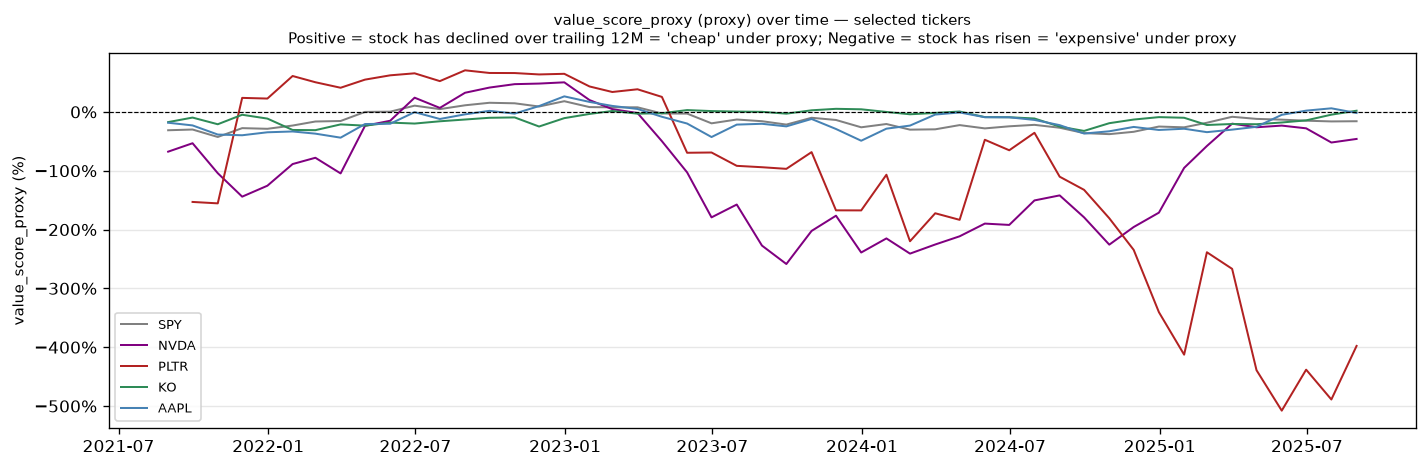

In [9]:
FOCUS = ["SPY", "NVDA", "PLTR", "KO", "AAPL"]
colors = ["gray", "purple", "firebrick", "seagreen", "steelblue"]

fig, ax = plt.subplots(figsize=(12, 4))
for ticker, color in zip(FOCUS, colors):
    ts = scores[scores["ticker"] == ticker].set_index("date")["value_score_proxy"]
    ax.plot(ts.index, ts * 100, label=ticker, color=color, linewidth=1.2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
ax.set_title(
    "value_score_proxy (proxy) over time — selected tickers\n"
    "Positive = stock has declined over trailing 12M = 'cheap' under proxy; "
    "Negative = stock has risen = 'expensive' under proxy",
    fontsize=9,
)
ax.set_ylabel("value_score_proxy (%)", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("value_score_time_series.png", bbox_inches="tight")
plt.show()

## 9 · Quality checklist

| Check | Status |
|---|---|
| Proxy nature stated in module docstring, notebook title, and all column/variable names (`_proxy` suffix) | ✓ |
| `value_score_proxy` direction documented: high = fallen more = "cheap" under proxy | ✓ |
| No skip-most-recent-month logic (that is momentum-only) | ✓ |
| Tickers with insufficient history excluded with logged reason — not NaN'd | ✓ |
| Rebalance dates come from `get_rebalance_dates()` — shared with Task 2/3 | ✓ |
| Manual spot-check on 3 tickers matches function output (np.isclose) | ✓ |
| Notebook runs top-to-bottom with Restart Kernel & Run All | ✓ |